In [29]:
import os
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

### ELG

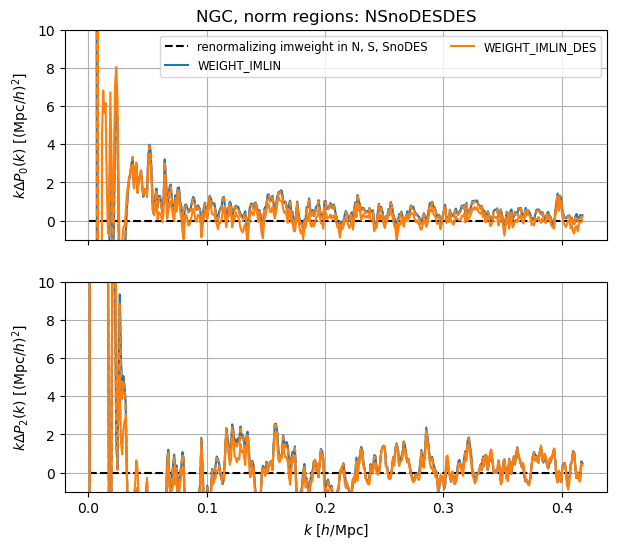

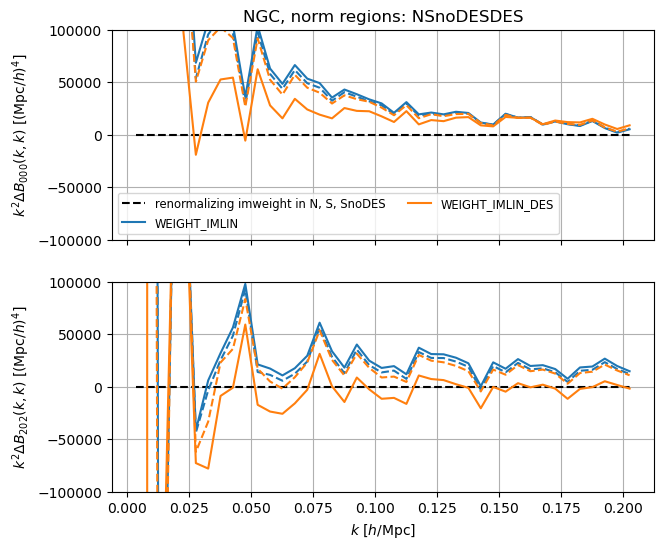

In [33]:
dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise3')
spectra = {}
region = 'NGC'
tracer = 'ELG_LOPnotqso'
norm_regions = 'NSnoDESDES'
for stat in ['mesh2_spectrum', 'mesh3_spectrum']:
    for imweight in ['WEIGHT_SYS', 'WEIGHT_IMLIN', 'WEIGHT_IMLIN_DES']:
        fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}_no-renorm-ran.h5'
        spectrum = types.read(fn)
        if 'mesh2' in spectrum:
            spectrum = spectrum.select(k=slice(0, None, 5))
        spectra[stat, norm_regions, imweight, None] = spectrum
        
        fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}_renorm-imweight_no-renorm-ran.h5'
        spectra[stat, norm_regions, imweight, 'renorm'] = types.read(fn).match(spectra[stat, norm_regions, 'WEIGHT_SYS', None])

ells = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].ells[:2]
fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
lax = lax.ravel()
for ill, ell in enumerate(ells):
    ax = lax[ill]
    ref = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
    k = ref.coords('k')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', 'renorm'].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='k', linestyle='--', label='renormalizing imweight in N, S, SnoDES')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', 'renorm'].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C0', linestyle='--')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', 'renorm'].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C1', linestyle='--')
    ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    ax.set_ylim(-1., 10.)
    ax.grid(True)
lax[0].legend(fontsize='small', ncols=2)
lax[0].set_title(f'{region}, norm regions: {norm_regions}')
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()

norm_regions = 'NSnoDESDES'
ells = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].ells
fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
lax = lax.ravel()
for ill, ell in enumerate(ells):
    ax = lax[ill]
    ref = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
    k = ref.coords('k')[..., 0]
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', 'renorm'].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='k', linestyle='--', label='renormalizing imweight in N, S, SnoDES')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN', 'renorm'].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', linestyle='--')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', 'renorm'].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C1', linestyle='--')
    ax.set_ylabel(rf'$k^2 \Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
    ax.set_ylim(-1e5, 1e5)
    ax.grid(True)
lax[0].legend(fontsize='small', ncols=2)
lax[0].set_title(f'{region}, norm regions: {norm_regions}')
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()

In [61]:
#dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise2')
dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise3')

region = 'SGC'
stats = ['mesh2_spectrum', 'mesh3_spectrum']
imweights = ['WEIGHT_SYS', 'WEIGHT_IMLIN', 'WEIGHT_IMLIN_DES', 'WEIGHT_IMLIN_DES_NORM_GLOBAL'][:1]
randomizes = ['constant', 'isotropic', 'angular', 'isotropic_norm', 'angular_norm'][:0]
norm_regions_list = ['NS', 'NSnoDESDES'][1:]

tracer = 'ELG_LOPnotqso'
spectra = {}

for stat in stats:
    for norm_regions in norm_regions_list:
        for imweight in imweights:
            for randomize in [None]:
                for renorm_randoms in [False, True]:
                    randomize_label = f'_randomize-{randomize}' if randomize else ''
                    renorm_randoms_label = '' if renorm_randoms else '_no-renorm-ran'
                    fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}{randomize_label}{renorm_randoms_label}.h5'
                    print(fn)
                    spectrum = types.read(fn)
                    #if stat == 'mesh2_spectrum':
                    #    spectrum = spectrum.select(k=slice(0, None, 5))
                    spectra[stat, norm_regions, imweight, randomize, renorm_randoms] = spectrum

/pscratch/sd/a/adematti/measurements/angular_shotnoise3/mesh2_spectrum_ELG_LOPnotqso_SGC_WEIGHT_SYS_normNSnoDESDES_no-renorm-ran.h5
/pscratch/sd/a/adematti/measurements/angular_shotnoise3/mesh2_spectrum_ELG_LOPnotqso_SGC_WEIGHT_SYS_normNSnoDESDES.h5
/pscratch/sd/a/adematti/measurements/angular_shotnoise3/mesh3_spectrum_ELG_LOPnotqso_SGC_WEIGHT_SYS_normNSnoDESDES_no-renorm-ran.h5
/pscratch/sd/a/adematti/measurements/angular_shotnoise3/mesh3_spectrum_ELG_LOPnotqso_SGC_WEIGHT_SYS_normNSnoDESDES.h5


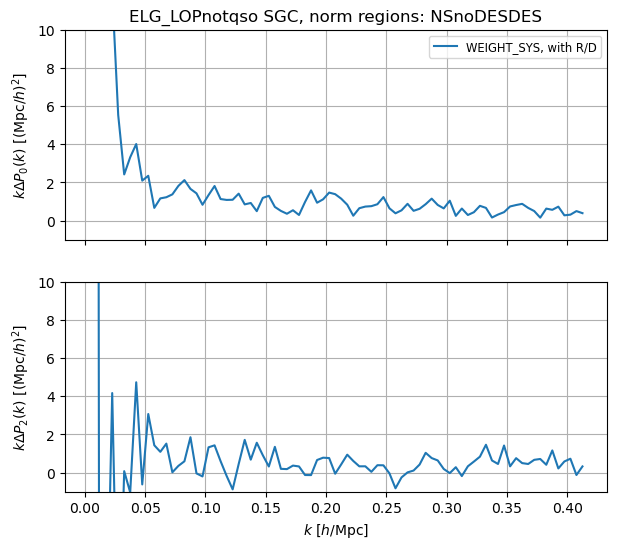

In [58]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None, False].ells[:2]
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None, False].get(ell)
        k = ref.coords('k')
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None, True].get(ell)
        ax.plot(k, k * (test.value() - ref.value()), color='C0', label='WEIGHT_SYS, with R/D')
        """
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None, True].get(ell)
        ax.plot(k, k * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN, with R/D')
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN_DES_NORM_GLOBAL', None, False].get(ell)
        ax.plot(k, k * (test.value() - ref.value()), color='C2', label='WEIGHT_IMLIN_DES_NORM_GLOBAL')
        """
        ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_ylim(-1., 10.)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

In [62]:
spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None, False].value().sum()

np.float64(3285781.273301805)

In [63]:
spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None, True].value().sum()

np.float64(5338657.792548365)

In [48]:
fn = '/pscratch/sd/a/adematti/measurements/angular_shotnoise2/mesh2_spectrum_ELG_LOPnotqso_SGC_WEIGHT_SYS_normNSnoDESDES.h5'
s1 = types.read(fn).select(k=slice(0, None, 5))
fn = '/pscratch/sd/a/adematti/measurements/angular_shotnoise2/mesh2_spectrum_ELG_LOPnotqso_SGC_WEIGHT_SYS_normNSnoDESDES_no-renorm-ran.h5'
s2 = types.read(fn).select(k=slice(0, None, 5))
print(s2.value() - s1.value())


[-2.13119850e+03 -1.60523414e+03  1.20149948e+03  1.03556118e+03
  2.81627639e+02 -3.12906191e+02  1.34407885e+03  1.02457788e+03
  9.12730389e+02  3.86329809e+02 -3.56569928e+01  5.16887787e+01
 -9.31556767e+00  5.22979080e+01  2.41722097e+02 -1.07043730e+02
 -4.13026029e+02 -1.00321209e+02  1.17203151e+02  1.92942603e+02
  6.05966807e+01 -2.39520017e+02 -9.35401180e+01  1.69564982e+02
  2.03942334e+01 -3.98748379e+01  4.00151540e+01  2.13879556e+02
  1.84921673e+02 -7.15589423e+01  1.03090761e+00  8.66104811e+01
  5.40632829e+01  2.48375301e+01  2.81182243e+01  8.47796895e+01
 -6.26316992e+01 -1.19286962e+01  9.05762681e+01  6.08902077e+01
 -1.10760241e+02 -4.11784452e+01 -6.65262472e+01 -5.01130096e+01
  9.67065693e+01  2.56180454e+01 -9.59642180e+00  2.59125208e+00
  2.32212595e+01 -3.04237618e+01  5.26634169e+01  5.29506577e+01
 -6.97072399e+00 -9.38492511e+00  2.48834367e+01  5.63763518e+01
  1.31737525e+01 -7.66573506e+01 -3.76760756e+01  1.61198528e+01
 -2.72430031e+01  1.98029

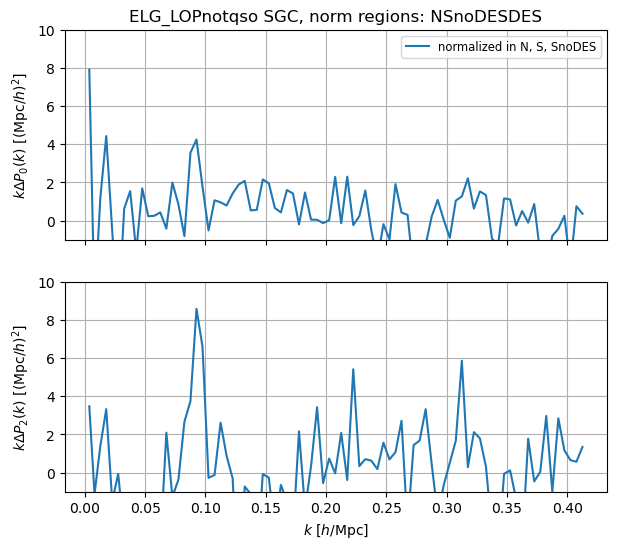

In [22]:
for norm_regions in norm_regions_list:
    ells = spectra1['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].ells[:2]
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra2['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')
        test = spectra1['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        ax.plot(k, k * (test.value() - ref.value()), color='C0', label='normalized in N, S, SnoDES')
        ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_ylim(-1., 10.)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

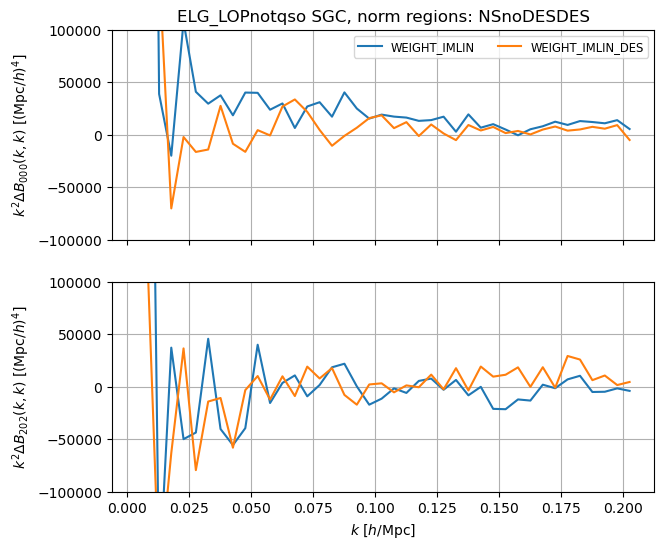

In [19]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].ells
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')[..., 0]
        test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
        ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
        #ax.plot(k, k**2 * ((test.value() + test.values('shotnoise')) - (ref.value() + ref.values('shotnoise'))), color='C0', label='WEIGHT_IMLIN')
        test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
        ax.plot(k, k**2 * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
        #ax.plot(k, k**2 * ((test.value() + test.values('shotnoise')) - (ref.value() + ref.values('shotnoise'))), color='C1', label='WEIGHT_IMLIN_DES')
        for irandomize, randomize in enumerate(randomizes):
            ax.plot(k, k**2 * (spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', randomize].get(ell).value() - ref.value()),
                    color=f'C{2 + irandomize:d}', linestyle='--', label=f'WEIGHT_IMLIN_DES {randomize}')
        ax.set_ylabel(rf'$k^2 \Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
        ax.set_ylim(-1e5, 1e5)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

### QSO

In [31]:
dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise2')

region = 'SGC'
stats = ['mesh2_spectrum', 'mesh3_spectrum']
imweights = ['WEIGHT_SYS', 'WEIGHT_ONE']
randomizes = []
norm_regions_list = ['NS', 'NSnoDESDES'][1:]
tracer = 'QSO'

spectra = {}
for stat in stats:
    for norm_regions in norm_regions_list:
        for imweight in imweights:
            for randomize in [None] + randomizes:
                if randomize is not None and imweight != 'WEIGHT_ONE':
                    continue  # randomize shown for WEIGHT_ONE only
                randomize_label = f'_randomize-{randomize}' if randomize else ''
                fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}{randomize_label}.h5'
                print(fn)
                spectrum = types.read(fn)
                if stat == 'mesh2_spectrum':
                    spectrum = spectrum.select(k=slice(0, None, 5))
                spectra[stat, norm_regions, imweight, randomize] = spectrum

/pscratch/sd/a/adematti/measurements/angular_shotnoise2/mesh2_spectrum_QSO_SGC_WEIGHT_SYS_normNSnoDESDES.h5
/pscratch/sd/a/adematti/measurements/angular_shotnoise2/mesh2_spectrum_QSO_SGC_WEIGHT_ONE_normNSnoDESDES.h5
/pscratch/sd/a/adematti/measurements/angular_shotnoise2/mesh3_spectrum_QSO_SGC_WEIGHT_SYS_normNSnoDESDES.h5
/pscratch/sd/a/adematti/measurements/angular_shotnoise2/mesh3_spectrum_QSO_SGC_WEIGHT_ONE_normNSnoDESDES.h5


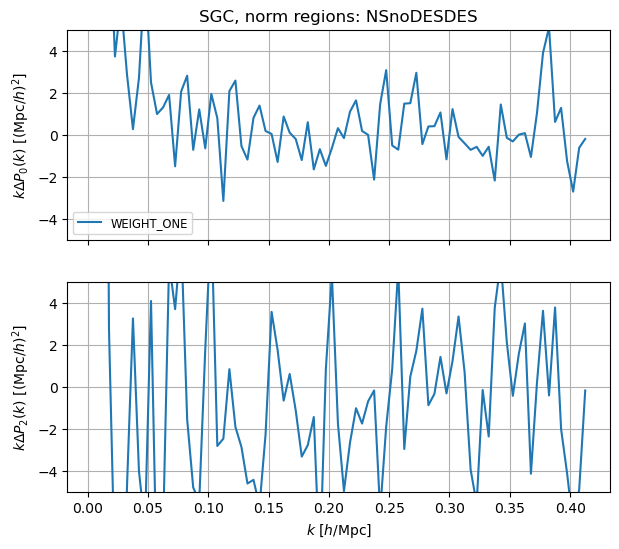

In [32]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].ells[:2]
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_ONE', None].get(ell)
        ax.plot(k, k * (test.value() - ref.value()), color='C0', label='WEIGHT_ONE')
        ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_ylim(-5., 5.)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

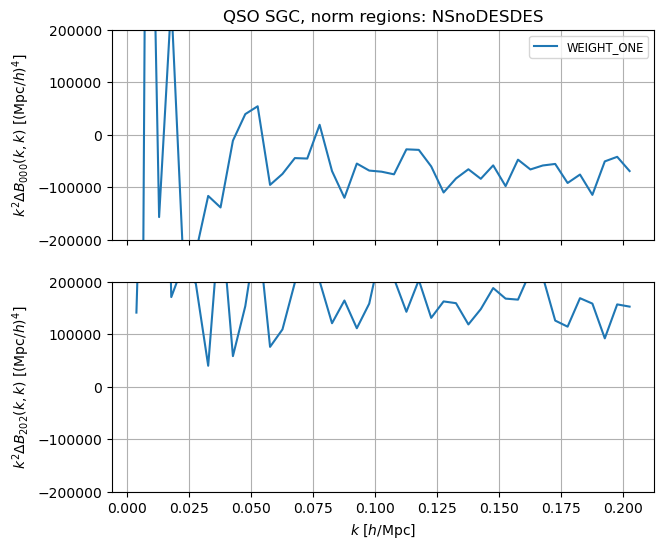

In [33]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].ells
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')[..., 0]
        test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_ONE', None].get(ell)
        ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', label='WEIGHT_ONE')
        ax.set_ylabel(rf'$k^2 \Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
        ax.set_ylim(-2e5, 2e5)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

In [69]:
from mpytools import Catalog

cat_dir = tools.desi_dir / 'survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL'
print(cat_dir)

def get_catalog_fn(kind='data', tracer='ELG_LOPnotqso', region='NGC', iran=0):
    """Return fNL clustering catalog filename."""
    if kind == 'data':
        return cat_dir / f'{tracer}_{region}_clustering.dat.fits'
    return cat_dir / f'{tracer}_{region}_{iran:d}_clustering.ran.fits'

/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL


In [74]:
tracer = 'QSO'
regions = ['NGC', 'SGC']
data = Catalog.read([get_catalog_fn(kind='data', tracer=tracer, region=region) for region in regions])
data[data.columns()]
randoms = Catalog.read([get_catalog_fn(kind='randoms', tracer=tracer, region=region) for region in regions])
randoms[randoms.columns()]

zranges = [None, (0.8, 2.1)]

In [75]:
regions = ['N', 'SnoDES', 'DES']

def get_alphas(wdata, wrandoms, regions=regions, zrange=None):
    sum_data_weights, sum_randoms_weights = [], []
    for region in regions:
        mask_data = tools.select_region(data['RA'], data['DEC'], region)
        mask_randoms = tools.select_region(randoms['RA'], randoms['DEC'], region)
        if zrange is not None:
            mask_data &= (data['Z'] > zrange[0]) & (data['Z'] < zrange[1])
            mask_randoms &= (randoms['Z'] > zrange[0]) & (randoms['Z'] < zrange[1])
        sum_data_weights.append(wdata[mask_data].sum())
        sum_randoms_weights.append(wrandoms[mask_randoms].sum())
    sum_data_weights, sum_randoms_weights = np.array(sum_data_weights), np.array(sum_randoms_weights)
    alphas = sum_data_weights / sum_randoms_weights / (sum(sum_data_weights) / sum(sum_randoms_weights))
    return np.array(alphas)

print(data.csize, randoms.csize)
for zrange in zranges:
    print(f'In zrange = {zrange}', get_alphas(data['WEIGHT'], randoms['WEIGHT'], zrange=zrange))

2180571 27929969
In zrange = None [1.00028747 0.99994391 0.99978262]
In zrange = (0.8, 2.1) [0.99991767 0.99997198 1.00039774]


In [ ]:
def match_data_column(randoms, data):
    sorted_index = np.argsort(data['TARGETID'])
    index_in_sorted = np.searchsorted(data['TARGETID'][sorted_index], randoms['TARGETID_DATA'])
    index = sorted_index[np.clip(index_in_sorted, 0, len(sorted_index) - 1)]
    return index

index = match_data_column(randoms, data)
ratio = data['WEIGHT_IMLIN_DES_NORM_GLOBAL'] / data['WEIGHT_SYS']

for zrange in zranges:
    print(f'In zrange = {zrange}', get_alphas(data['WEIGHT'] * ratio, randoms['WEIGHT'] * ratio[index], zrange=zrange))